## Análise de Churn

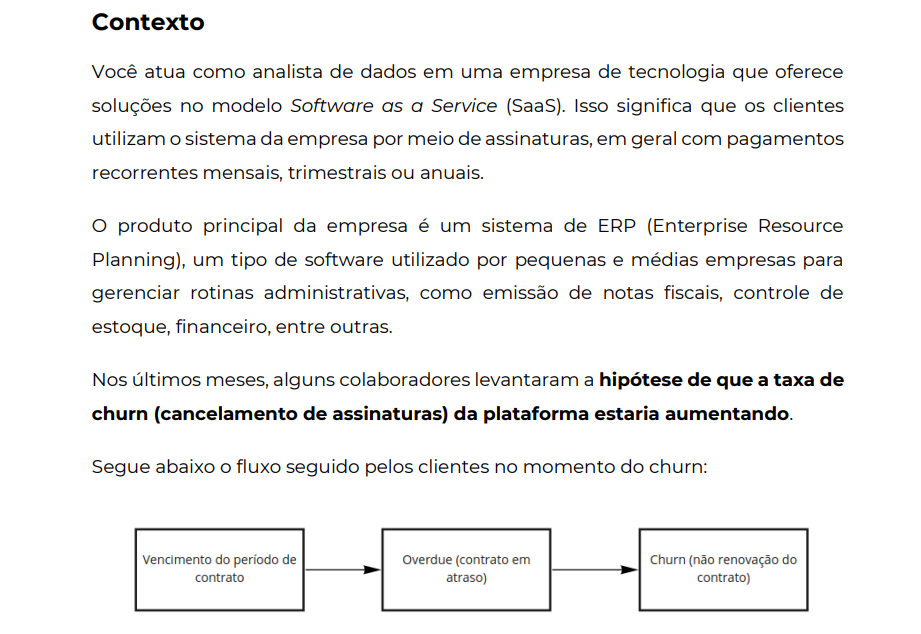
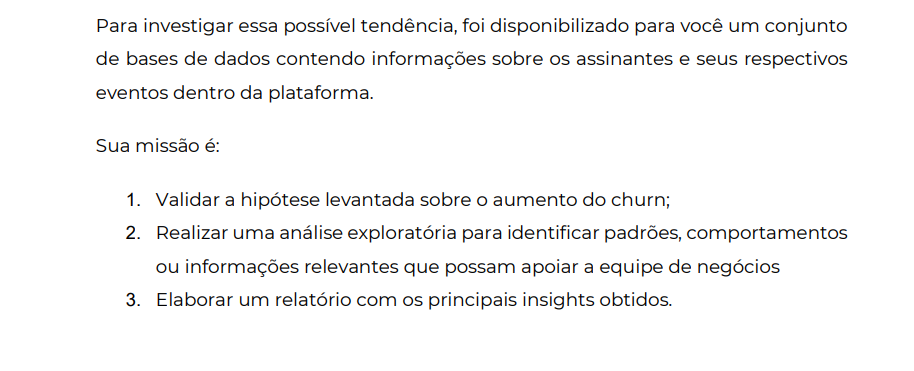

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
df = pd.read_csv("C:\\Users\\João Luís\\Desktop\\analise-de-churn\\data\\customer_churn_with_months.csv")
df

,ID,Tipo de empresa,Fundação da empresa,Possui mais de um sócio,Funcionários,Meses de permanência,Utiliza serviços financeiros,PossuiContador,Faz conciliação bancária,Frequência de utilização de feature do sistema: Módulo financeiro,...,Frequência de utilização de feature do sistema: Relatórios,Frequência de utilização de feature do sistema: Utilização de APIs de integração,Contrato,Emite boletos,Emite boletos.1,Tipo de pagamento,Receita mensal,Receita total,Churn,mes_churn
0,1,Micro empresa,2016,Sim,até 5 funcionários,1,Não,NaN,automática,Pouco uso,...,Pouco uso,Pouco uso,Mês-a-mês,1,Yes,Boleto - pagamento único,29.85,29.85,Não,NaN
1,2,Pequena empresa,2018,Não,até 5 funcionários,34,Sim,Não,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Boleto - mês a mês,56.95,1889.50,Não,NaN
2,4,Pequena empresa,2016,Não,até 5 funcionários,45,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Trimestral,0,No,Cartão de crédito - pagamento único,42.30,1840.75,Não,NaN
3,7,Pequena empresa,2019,Não,6 ou mais funcionários,22,Sim,Sim,manual,Pouco uso,...,Uso frequente,Pouco uso,Mês-a-mês,1,Yes,Cartão de crédito - mês a mês,89.10,1949.40,Não,NaN
4,8,Micro empresa,2019,Não,até 5 funcionários,10,Não,NaN,automática,Uso frequente,...,Pouco uso,Pouco uso,Mês-a-mês,0,No,Boleto - mês a mês,29.75,301.90,Não,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4308,Micro empresa,2014,Não,até 5 funcionários,37,Sim,Sim,manual,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - pagamento único,96.55,3580.30,Sim,05/2025
7039,4950,Pequena empresa,2020,Não,até 5 funcionários,5,Não,NaN,automática,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - mês a mês,51.00,305.95,Sim,05/2025
7040,3303,Pequena empresa,2016,Não,até 5 funcionários,31,Sim,Sim,manual,Pouco uso,...,Uso frequente,Uso frequente,Trimestral,1,Yes,Boleto - pagamento único,103.45,3066.45,Sim,05/2025
7041,5548,Micro empresa,2016,Não,até 5 funcionários,3,Sim,Não,manual,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - pagamento único,89.45,240.45,Sim,05/2025


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                                                            Non-Null Count  Dtype  
---  ------                                                                            --------------  -----  
 0   ID                                                                                7043 non-null   int64  
 1   Tipo de empresa                                                                   7043 non-null   str    
 2   Fundação da empresa                                                               7043 non-null   int64  
 3   Possui mais de um sócio                                                           7043 non-null   str    
 4   Funcionários                                                                      7043 non-null   str    
 5   Meses de permanência                                                              7043 non-null   int64  
 6   Utiliza ser

In [34]:
df.isnull().sum()

ID                                                                                     0
Tipo de empresa                                                                        0
Fundação da empresa                                                                    0
Possui mais de um sócio                                                                0
Funcionários                                                                           0
Meses de permanência                                                                   0
Utiliza serviços financeiros                                                           0
PossuiContador                                                                       682
Faz conciliação bancária                                                               0
Frequência de utilização de feature do sistema: Módulo financeiro                      0
Frequência de utilização de feature do sistema: Emissão de nota fiscal                 0
Frequência de utiliza

In [35]:
df["Churn"].value_counts()

Churn
Não    5174
Sim    1869
Name: count, dtype: int64

In [36]:
df["mes_churn"].value_counts()

mes_churn
05/2025    958
04/2025    911
Name: count, dtype: int64

In [37]:
(958-911)/911 * 100

5.159165751920966

Hipotese sobre o aumenteo do Churn validade, no mês de março tivemos 911 cancelamentos e no mês de maio tivemos 958, isso mostra um aumento de 5.15%

In [38]:
df_filtrado = df[df["Churn"] == "Sim"]

df_filtrado

,ID,Tipo de empresa,Fundação da empresa,Possui mais de um sócio,Funcionários,Meses de permanência,Utiliza serviços financeiros,PossuiContador,Faz conciliação bancária,Frequência de utilização de feature do sistema: Módulo financeiro,...,Frequência de utilização de feature do sistema: Relatórios,Frequência de utilização de feature do sistema: Utilização de APIs de integração,Contrato,Emite boletos,Emite boletos.1,Tipo de pagamento,Receita mensal,Receita total,Churn,mes_churn
5174,6445,Pequena empresa,2020,Não,6 ou mais funcionários,31,Sim,Sim,automática,Pouco uso,...,Uso frequente,Uso frequente,Trimestral,1,Yes,Boleto - mês a mês,79.45,2587.70,Sim,04/2025
5175,5635,Micro empresa,2017,Sim,6 ou mais funcionários,1,Sim,Não,não faz,Nunca utilizou,...,Nunca utilizou,Nunca utilizou,Mês-a-mês,1,Yes,Boleto - pagamento único,19.90,19.90,Sim,04/2025
5176,3529,Pequena empresa,2018,Não,até 5 funcionários,16,Sim,Não,não faz,Nunca utilizou,...,Nunca utilizou,Nunca utilizou,Mês-a-mês,1,Yes,Boleto - mês a mês,19.70,342.40,Sim,04/2025
5177,1058,Micro empresa,2018,Não,até 5 funcionários,10,Sim,Não,manual,Uso frequente,...,Uso frequente,Pouco uso,Mês-a-mês,1,Yes,Boleto - mês a mês,84.70,832.05,Sim,04/2025
5178,1580,Pequena empresa,2014,Sim,até 5 funcionários,12,Sim,Não,manual,Pouco uso,...,Pouco uso,Uso frequente,Mês-a-mês,1,Yes,Boleto - pagamento único,80.45,950.20,Sim,04/2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4308,Micro empresa,2014,Não,até 5 funcionários,37,Sim,Sim,manual,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - pagamento único,96.55,3580.30,Sim,05/2025
7039,4950,Pequena empresa,2020,Não,até 5 funcionários,5,Não,NaN,automática,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - mês a mês,51.00,305.95,Sim,05/2025
7040,3303,Pequena empresa,2016,Não,até 5 funcionários,31,Sim,Sim,manual,Pouco uso,...,Uso frequente,Uso frequente,Trimestral,1,Yes,Boleto - pagamento único,103.45,3066.45,Sim,05/2025
7041,5548,Micro empresa,2016,Não,até 5 funcionários,3,Sim,Não,manual,Pouco uso,...,Uso frequente,Uso frequente,Mês-a-mês,1,Yes,Boleto - pagamento único,89.45,240.45,Sim,05/2025


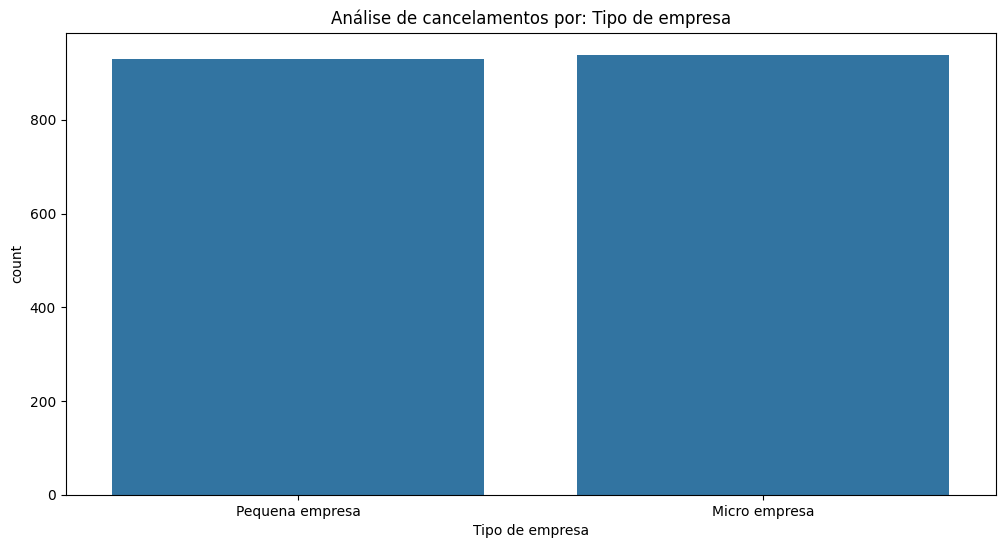

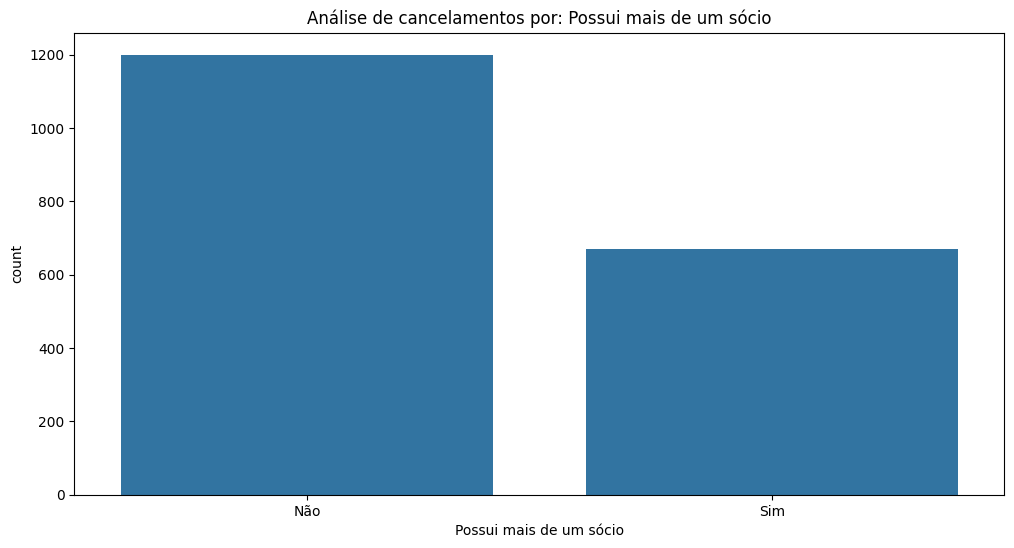

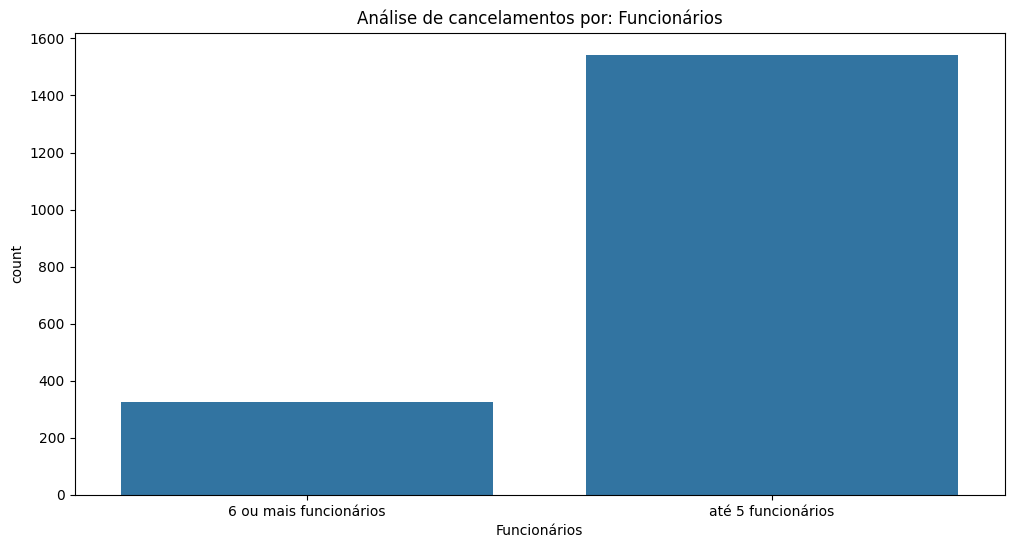

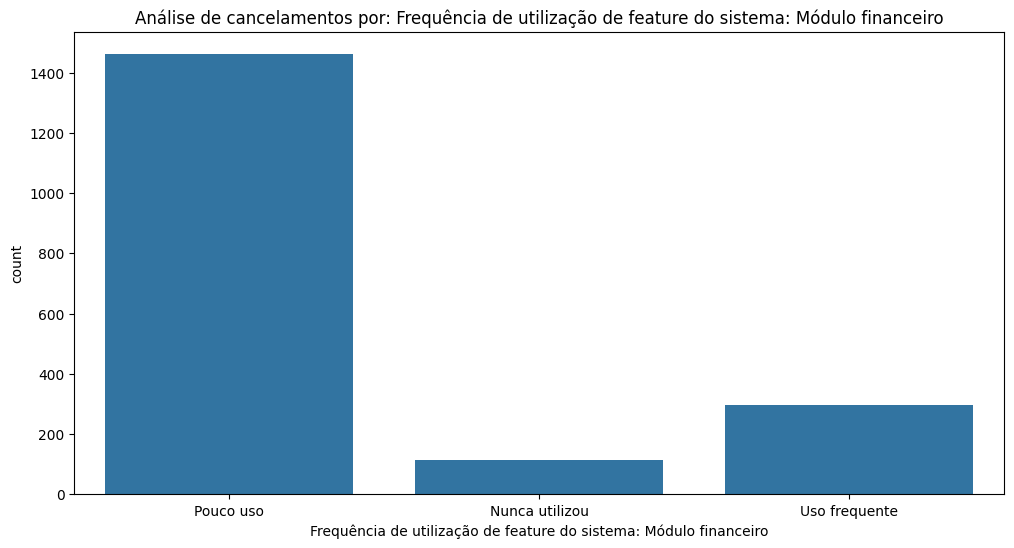

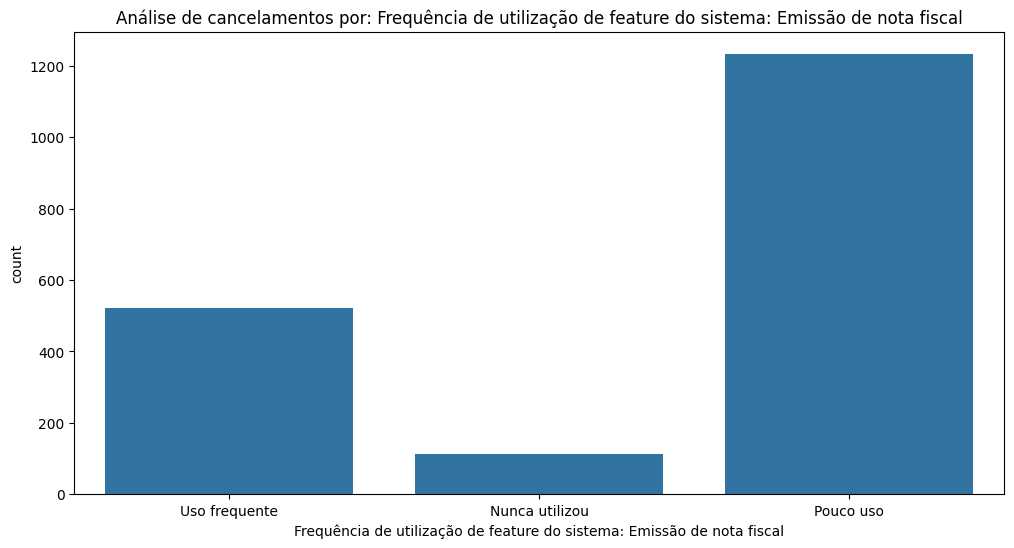

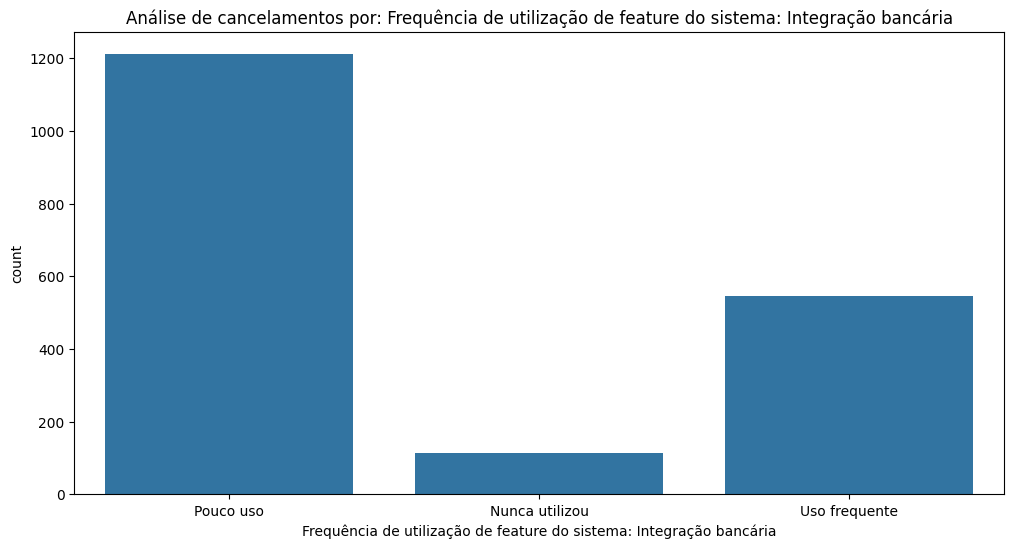

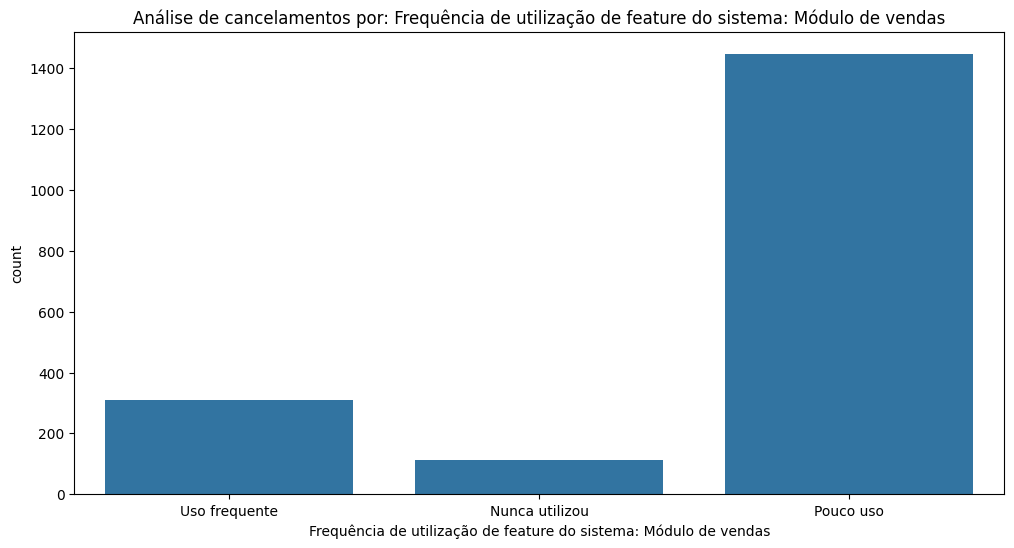

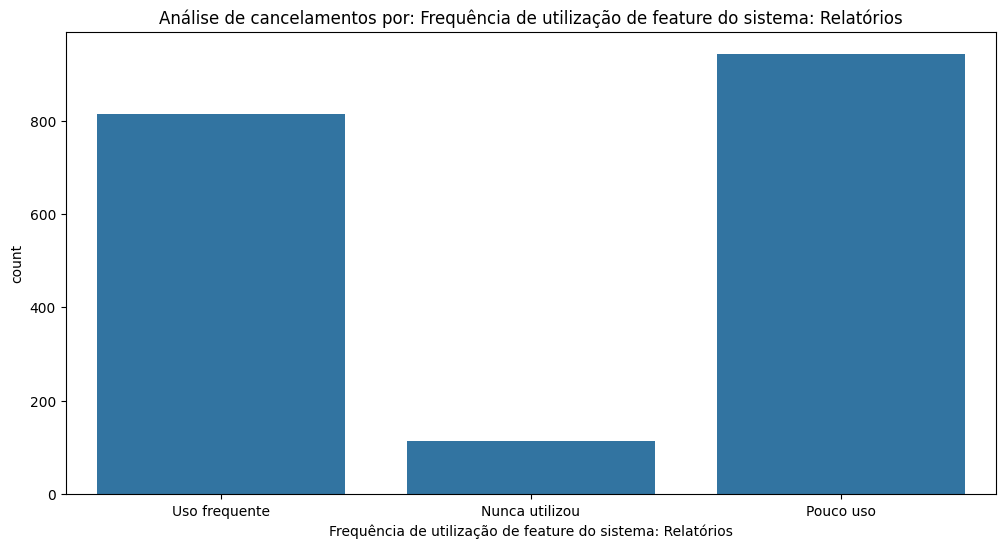

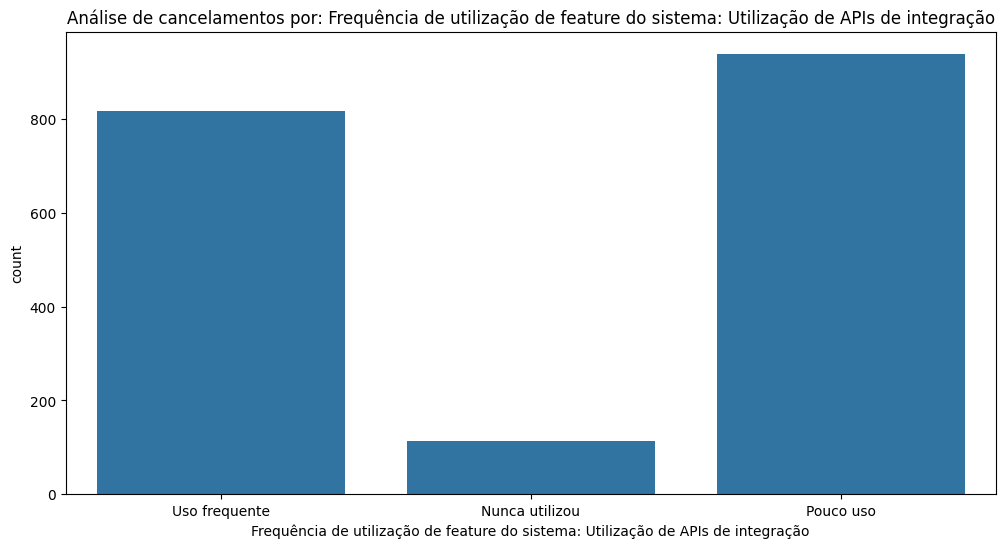

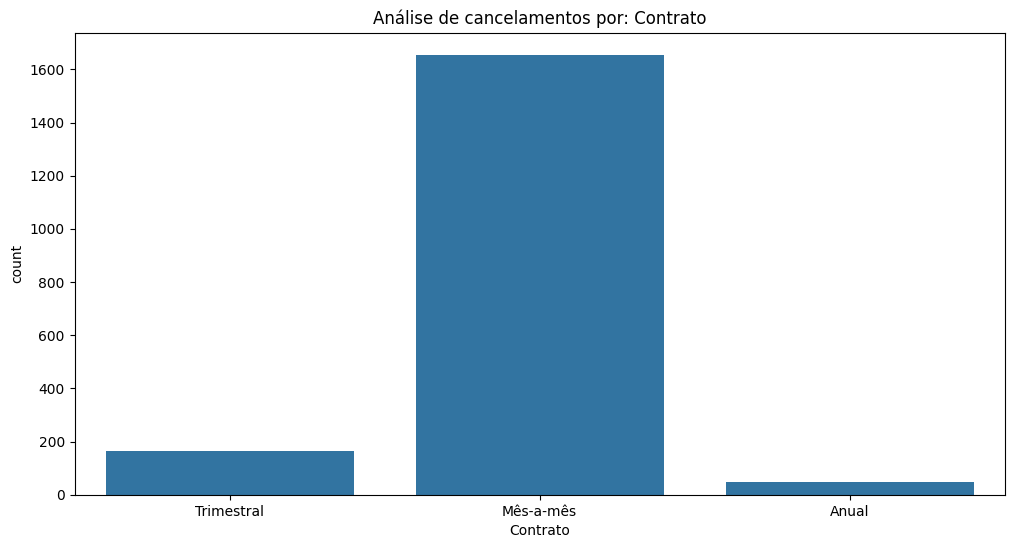

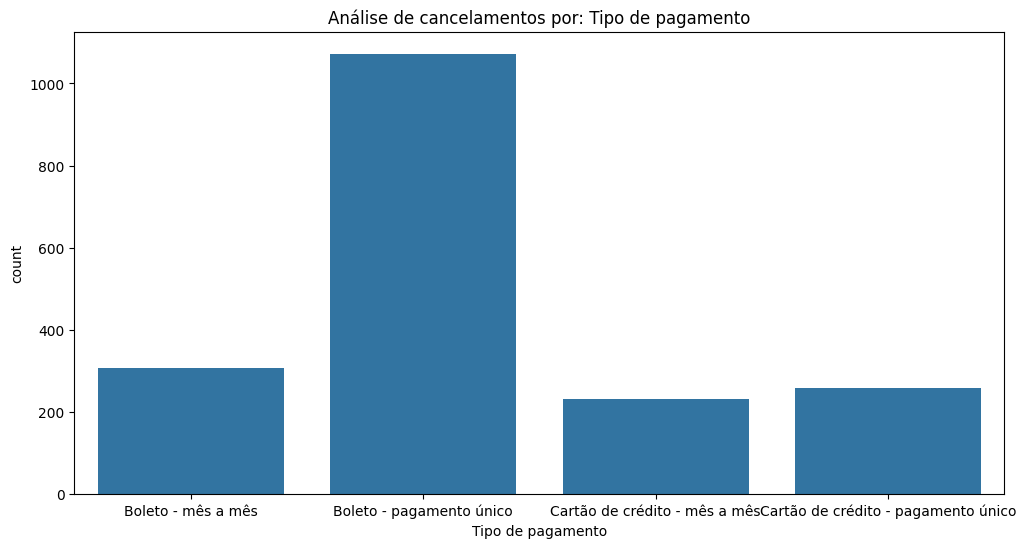

In [47]:
colunas_analisar = ['Tipo de empresa', 'Possui mais de um sócio','Funcionários', 'Frequência de utilização de feature do sistema: Módulo financeiro', 
'Frequência de utilização de feature do sistema: Emissão de nota fiscal', 'Frequência de utilização de feature do sistema: Integração bancária', 'Frequência de utilização de feature do sistema: Módulo de vendas', 
'Frequência de utilização de feature do sistema: Relatórios', 'Frequência de utilização de feature do sistema: Utilização de APIs de integração', 'Contrato','Tipo de pagamento']
for col in colunas_analisar:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_filtrado, x= col)
    plt.title(f"Análise de cancelamentos por: {col}")
    plt.show()

# Principais Insights:
1. Empresas de pequeno porte (Pequenas e Microempresas), apareceu em 100% dos cancelamentos
   - A taxa de utilização dos serviços do SaaS, mostram que essas empresas não fazem o uso frequente das ferramentas, por isso o cancelamento.
   - O cancelamento também tem forte influencia no tipo do contrato, seria melhor focar em planos trimestrais e anuais.
   - O pagamento via boleto também tem maior taxa de cancelamento, pode ser por causa da burocracia e falta de praticidade na hora do pagamento
# Possiveis Soluções
- Focar em desenvolver ferramentas que atendem mais as pequenas empresas ou um tipo de plano especial para elas, onde pagam um valor menor por exemplo
- Sobre o tipo de contrato, seria interessante descontos para os planos anuais e trimestrais, buscando mais vendas para esses tipos
- deixar o cartão de crédito como uma tipo de pagamento padrão, também seria o ideal